# 05 — Continuous Stochastic Order Model (Figure 5)

**Question**: Can a continuous SDE for polarisation,
coupled to age-and-order-dependent killing, reproduce the empirical run statistics?

## Model
$$dp = b(p)\,dt + \sigma(p)\,dW_t, \quad p \in [0,1]$$

Killing rate:
$$\phi(a, p) = \left[\lambda_\infty + \frac{\mu}{a_0+a}\right] \exp\bigl(\beta\, z_p\bigr)$$

## Panels
| Panel | Content |
|-------|---------|
| **A** | Sample polarisation time series (3 runs of varied phenotype) |
| **B** | Estimated drift $b(p)$ and diffusion $\sigma^2(p)$ vs $p$ |
| **C** | State-dependent killing rate $\phi(p)$ at fixed age $a=10s$ |
| **D** | Empirical vs. simulated polarisation histogram |
| **E** | Empirical vs. simulated run-duration CCDF |

**Key result**: A two-parameter SDE + age-and-order hazard reproduces transport statistics.

**Prerequisite**: Run `01_data_loading.ipynb` and `04_hazard_mechanism.ipynb` first.

In [1]:
import sys, os
from pathlib import Path

_HERE = Path(os.getcwd())
_REPO = _HERE.parents[2]
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from analysis.levy_paper.util.paper_utils import (
    configure_paper_plotting,
    load_cache, save_figure,
    plot_ccdf,
    STATE_COLORS, A0, N_SIM,
)
configure_paper_plotting()

df_pmv        = load_cache("df_pmv")
centroid_runs = load_cache("centroid_order_runs")
haz_intervals = load_cache("hazard_intervals")

print(f"PMV rows: {len(df_pmv):,}")

PMV rows: 89,947


## Panel A — Sample Polarisation Time Series

Show 3 representative centroid runs: low, mid, and high mean polarisation.
Highlights the diversity of order phenotypes.

In [ ]:
# Select representative runs — require at least 10s duration for a visible trace
long_runs = centroid_runs.loc[centroid_runs["duration_s"] >= 10].copy()
quantiles = long_runs["p_mean"].quantile([0.1, 0.5, 0.9])

example_ids = {}
for q_name, q_val in zip(["low (p10)", "mid (p50)", "high (p90)"],
                          quantiles.values):
    idx = (long_runs["p_mean"] - q_val).abs().idxmin()
    example_ids[q_name] = long_runs.loc[idx, "run_id"]

example_traces = {}   # stored for reuse in figure assembly

fig_A, axes_A = plt.subplots(3, 1, figsize=(7, 5), sharex=False)

for ax, (label, run_id) in zip(axes_A, example_ids.items()):
    row = centroid_runs.loc[centroid_runs["run_id"] == run_id].iloc[0]
    mask = (
        (df_pmv["match_id"] == row["match_id"]) &
        (df_pmv["team"]     == row["team"]) &
        (df_pmv["_t"]       >= row["t_start"]) &
        (df_pmv["_t"]       <= row["t_end"])
    )
    trace = df_pmv.loc[mask, "p_group"]
    example_traces[label] = trace.values

    t = np.arange(len(trace))
    color = STATE_COLORS["low" if "low" in label else ("high" if "high" in label else "mid")]
    ax.plot(t, trace.values, color=color, lw=1.0)
    ax.axhline(trace.mean(), color=color, ls="--", lw=0.8, alpha=0.7)
    ax.set_ylabel("$p(t)$")
    ax.set_ylim(0, 1)
    ax.set_title(f"{label}  ($\\bar p$={trace.mean():.2f})", fontsize=9)

axes_A[-1].set_xlabel("Time within run (s)")
fig_A.suptitle("A — Sample polarisation time series", y=1.01)
plt.tight_layout()
plt.show()

## Panel B — Drift and Diffusion Estimation

Estimate the Fokker–Planck drift $b(p)$ and diffusion coefficient $\sigma^2(p)$
from the empirical increments:
$$b(p) \approx \frac{\langle \Delta p \mid p \rangle}{\Delta t}, \quad
\sigma^2(p) \approx \frac{\langle (\Delta p)^2 \mid p \rangle}{\Delta t}$$

C:\Users\Daniel\AppData\Local\Temp\ipykernel_12728\855739393.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-o" (-> color='k'). The keyword argument will take precedence.
  ax_B2.plot(bin_labels, diffusion, "k-o", ms=4, color="#4393c3")


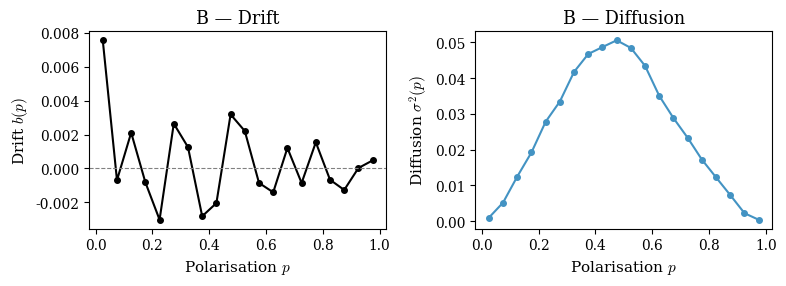

In [3]:
# Compute increments per match/team to avoid cross-boundary artifacts
pmv_sorted = df_pmv.sort_values(["match_id", "team", "_t"]).copy()

dp_list, p_mid_list = [], []
for _, grp in pmv_sorted.groupby(["match_id", "team"], observed=True):
    p_grp = grp["p_group"].values
    if len(p_grp) < 2:
        continue
    dp_list.append(np.diff(p_grp))
    p_mid_list.append(0.5 * (p_grp[:-1] + p_grp[1:]))

dp    = np.concatenate(dp_list)
p_mid = np.concatenate(p_mid_list)

# Bin by p value
bins = np.linspace(0, 1, 21)
bin_labels = 0.5 * (bins[:-1] + bins[1:])
bin_idx = np.clip(np.digitize(p_mid, bins) - 1, 0, len(bins) - 2)

drift = np.zeros(len(bin_labels))
diffusion = np.zeros(len(bin_labels))
for k in range(len(bin_labels)):
    sel = dp[bin_idx == k]
    if len(sel) > 5:
        drift[k]     = np.mean(sel)
        diffusion[k] = np.var(sel)

fig_B, (ax_B1, ax_B2) = plt.subplots(1, 2, figsize=(8, 3))

ax_B1.plot(bin_labels, drift, "k-o", ms=4)
ax_B1.axhline(0, color="grey", lw=0.8, ls="--")
ax_B1.set_xlabel("Polarisation $p$"); ax_B1.set_ylabel("Drift $b(p)$")
ax_B1.set_title("B — Drift")

ax_B2.plot(bin_labels, diffusion, "k-o", ms=4, color="#4393c3")
ax_B2.set_xlabel("Polarisation $p$"); ax_B2.set_ylabel(r"Diffusion $\sigma^2(p)$")
ax_B2.set_title("B — Diffusion")

plt.tight_layout()
plt.show()

## Fit Simple Parametric SDE

Model: Ornstein–Uhlenbeck-like process on $p \in [0,1]$:
$$dp = \theta(\mu_p - p)\,dt + \sigma_p\,dW_t$$
reflected at $[0,1]$.  Fit via moment matching.

In [4]:
def fit_ou_params(p_series: np.ndarray) -> dict:
    """
    Fit Ornstein-Uhlenbeck parameters (theta, mu, sigma) from a
    polarisation time series via maximum-likelihood (discrete approximation).
    """
    p = p_series[~np.isnan(p_series)]
    dp = np.diff(p)
    p_prev = p[:-1]

    # OLS: dp = (theta*mu)*dt - theta*p*dt + eps
    X = np.column_stack([np.ones_like(p_prev), p_prev])
    coeffs, _, _, _ = np.linalg.lstsq(X, dp, rcond=None)
    theta_mu, neg_theta = coeffs
    theta = -neg_theta
    mu    = theta_mu / theta if theta > 1e-8 else np.mean(p)
    sigma = np.std(dp - X @ coeffs)

    return {"theta": max(theta, 0.0), "mu_p": np.clip(mu, 0, 1), "sigma": max(sigma, 0.0)}


ou_params = fit_ou_params(df_pmv["p_group"].dropna().values)
print("OU parameters:", {k: round(v, 4) for k, v in ou_params.items()})

OU parameters: {'theta': np.float64(0.2211), 'mu_p': np.float64(0.6466), 'sigma': np.float64(0.1516)}


## Panel C — State-Dependent Killing Rate

How does the instantaneous hazard $\phi(p)$ vary with polarisation at fixed age $a=10s$?

C:\Users\Daniel\AppData\Local\Temp\ipykernel_12728\3648223669.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("p_bin")["event"]


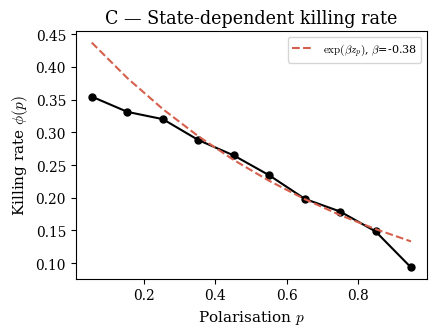

In [5]:
# Fit the hazard model: phi(a,p) = [lambda_inf + mu/(a0+a)] * exp(beta * z(p))
# Use binned empirical hazard across age × p bins

# Bin polarisation in hazard_intervals
haz_intervals_p = haz_intervals.copy()
haz_intervals_p["p_bin"] = pd.cut(haz_intervals_p["p_group"], bins=10)

phi_by_p = (
    haz_intervals_p
    .groupby("p_bin")["event"]
    .agg(events="sum", at_risk="count")
    .assign(phi=lambda d: d["events"] / d["at_risk"])
    .reset_index()
)
p_centres_phi = [iv.mid for iv in phi_by_p["p_bin"]]

fig_C, ax_C = plt.subplots(figsize=(4.5, 3.5))
ax_C.plot(p_centres_phi, phi_by_p["phi"].values, "k-o", ms=5)

# Overlay exponential fit: phi(p) ∝ exp(beta * z(p))
p_arr = np.array(p_centres_phi, dtype=float)
phi_arr = phi_by_p["phi"].values
valid = phi_arr > 0
if valid.sum() > 3:
    z_p = (p_arr - p_arr.mean()) / (p_arr.std() + 1e-9)
    beta_fit = np.polyfit(z_p[valid], np.log(phi_arr[valid]), 1)[0]
    phi_fit  = np.exp(np.log(np.mean(phi_arr[valid])) + beta_fit * z_p)
    ax_C.plot(p_arr, phi_fit, "--", color="#d6604d",
              label=rf"$\exp(\beta z_p)$, $\beta$={beta_fit:.2f}")
    ax_C.legend(fontsize=8)

ax_C.set_xlabel("Polarisation $p$")
ax_C.set_ylabel(r"Killing rate $\phi(p)$")
ax_C.set_title("C — State-dependent killing rate")
plt.tight_layout()
plt.show()

## Panel D — Empirical vs. Simulated Polarisation Distribution

Does the fitted OU process reproduce the stationary distribution of $p$?

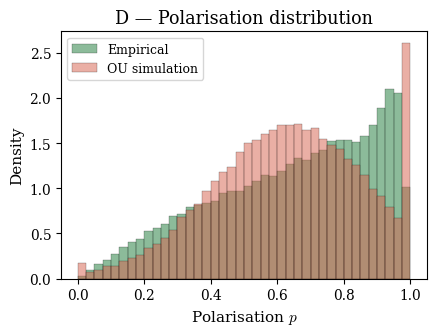

In [6]:
rng = np.random.default_rng(0)

def simulate_ou(theta: float, mu_p: float, sigma: float,
                n_steps: int = 10_000, dt: float = 1.0) -> np.ndarray:
    p = np.zeros(n_steps)
    p[0] = mu_p
    for t in range(1, n_steps):
        dp = theta * (mu_p - p[t-1]) * dt + sigma * np.sqrt(dt) * rng.standard_normal()
        p[t] = np.clip(p[t-1] + dp, 0.0, 1.0)
    return p

p_sim = simulate_ou(**ou_params, n_steps=50_000)
p_emp = df_pmv["p_group"].dropna().values

fig_D, ax_D = plt.subplots(figsize=(4.5, 3.5))
bins_p = np.linspace(0, 1, 41)
ax_D.hist(p_emp, bins=bins_p, density=True, alpha=0.5,
          color="#1b7837", label="Empirical", edgecolor="k", lw=0.3)
ax_D.hist(p_sim, bins=bins_p, density=True, alpha=0.5,
          color="#d6604d", label="OU simulation", edgecolor="k", lw=0.3)
ax_D.set_xlabel("Polarisation $p$")
ax_D.set_ylabel("Density")
ax_D.set_title("D — Polarisation distribution")
ax_D.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Panel E — Empirical vs. Simulated Run-Duration CCDF (Continuous Model)

Simulate runs under the OU process with continuous killing:
$$\phi(a, p) = \left[\lambda_\infty + \frac{\mu}{a_0+a}\right] e^{\beta z_p}$$

Simulating 20,000 continuous-model runs … done


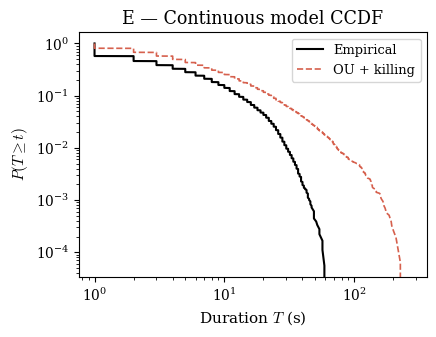

In [7]:
# Hazard parameters (from notebook 04 results — load or re-fit)
# Simple fallback values; replace with fitted params from 04 if available
LAM_INF = 0.02
MU_HAZ  = 1.0
BETA_P  = getattr(beta_fit if "beta_fit" in dir() else type("_", (), {"__getattr__": lambda s,n: -0.5})(), "__float__", lambda: -0.5)()
BETA_P  = float(beta_fit) if 'beta_fit' in dir() else -0.5

p_mean_global = float(df_pmv["p_group"].mean())
p_std_global  = float(df_pmv["p_group"].std())

def phi_continuous(a: float, p: float) -> float:
    z = (p - p_mean_global) / (p_std_global + 1e-9)
    return (LAM_INF + MU_HAZ / (A0 + a)) * np.exp(BETA_P * z)


def simulate_continuous_runs(n_runs: int, dt: float = 1.0,
                              max_t: float = 600.0) -> np.ndarray:
    durations = np.zeros(n_runs)
    for k in range(n_runs):
        p_t = ou_params["mu_p"]
        age = 0.0
        while age < max_t:
            h = phi_continuous(age, p_t)
            if rng.random() < h * dt:
                break
            dp_t = (ou_params["theta"] * (ou_params["mu_p"] - p_t) * dt
                    + ou_params["sigma"] * np.sqrt(dt) * rng.standard_normal())
            p_t = np.clip(p_t + dp_t, 0.0, 1.0)
            age += dt
        durations[k] = age
    return durations


print(f"Simulating {N_SIM:,} continuous-model runs …", end=" ")
cont_durations = simulate_continuous_runs(N_SIM)
print("done")

fig_E, ax_E = plt.subplots(figsize=(4.5, 3.5))
plot_ccdf(ax_E, centroid_runs["duration_s"], label="Empirical", color="black", lw=1.5)
plot_ccdf(ax_E, cont_durations, label="OU + killing", color="#d6604d", ls="--", lw=1.2)
ax_E.set_xlabel("Duration $T$ (s)")
ax_E.set_ylabel(r"$P(T \geq t)$")
ax_E.set_title("E — Continuous model CCDF")
ax_E.legend()
plt.tight_layout()
plt.show()

## Assemble and Save Figure 5

In [ ]:
fig5 = plt.figure(figsize=(14, 8))
gs = fig5.add_gridspec(2, 3, hspace=0.42, wspace=0.38)

ax5_A = fig5.add_subplot(gs[:, 0])   # tall left panel
ax5_B = fig5.add_subplot(gs[0, 1])
ax5_C = fig5.add_subplot(gs[0, 2])
ax5_D = fig5.add_subplot(gs[1, 1])
ax5_E = fig5.add_subplot(gs[1, 2])

# A — reuse stored traces from Panel A cell
for i, (label, trace) in enumerate(example_traces.items()):
    color = STATE_COLORS["low" if "low" in label else ("high" if "high" in label else "mid")]
    if len(trace) > 0:
        offset = i * 1.2
        ax5_A.plot(np.arange(len(trace)), trace + offset, color=color, lw=1.0, label=label)
ax5_A.set_ylabel("$p(t)$ (offset)"); ax5_A.set_xlabel("Time (s)")
ax5_A.set_title("A"); ax5_A.legend(fontsize=7)

# B
ax5_B.plot(bin_labels, drift, "k-o", ms=3)
ax5_B.axhline(0, color="grey", lw=0.7, ls="--")
ax5_B.set_xlabel("$p$"); ax5_B.set_ylabel("Drift"); ax5_B.set_title("B")

# C
ax5_C.plot(p_centres_phi, phi_by_p["phi"].values, "k-o", ms=4)
if 'beta_fit' in dir():
    ax5_C.plot(p_arr, phi_fit, "--", color="#d6604d")
ax5_C.set_xlabel("$p$"); ax5_C.set_ylabel(r"$\phi(p)$"); ax5_C.set_title("C")

# D
ax5_D.hist(p_emp, bins=bins_p, density=True, alpha=0.5, color="#1b7837", label="Empirical", edgecolor="k", lw=0.3)
ax5_D.hist(p_sim, bins=bins_p, density=True, alpha=0.5, color="#d6604d", label="OU sim", edgecolor="k", lw=0.3)
ax5_D.set_xlabel("$p$"); ax5_D.set_ylabel("Density"); ax5_D.set_title("D")
ax5_D.legend(fontsize=7)

# E
plot_ccdf(ax5_E, centroid_runs["duration_s"], label="Empirical", color="black")
plot_ccdf(ax5_E, cont_durations, label="OU+killing", color="#d6604d", ls="--")
ax5_E.set_xlabel("Duration (s)"); ax5_E.set_ylabel(r"$P(\geq)$")
ax5_E.set_title("E"); ax5_E.legend(fontsize=7)

fig5.suptitle("Figure 5 — Continuous Stochastic Order Model", fontsize=13)
save_figure(fig5, "figure5_stochastic_model")
plt.show()